# 1. How LaStBeRu is built:

The LaStBeRu pipeline processes ~31,500 systems. Here we follow **a single one** through it: the **Cosmic Horseshoe** (SDSS J114833.14+193003.2), an Einstein ring discovered in SDSS data and reported, among others, by:

| Paper | What it gives | Rows in its table |
|---|---|---|
| Diehl et al. (2009) – Sloan Bright Arcs Survey | $z_L$, $z_S$, $\theta_E$ | 4 |
| Stark et al. (2013) – CASSOWARY | $z_L$, $z_S$, *ugriz* magnitudes | 45 |
| Moustakas et al. (2012) – MasterLens | $z_L$, $z_S$, $\theta_E$ (SIE model), names | 11,629 |

```mermaid
flowchart LR
    A[Literature tables<br/>papers, VizieR, websites] -->|1. extraction| B[Processed catalogs<br/>one CSV per paper]
    B -->|2. merge| C[Records grouped<br/>into systems]
    C -->|3. cross-match| D[Photometric and<br/>spectroscopic surveys]
    C -->|4. cutouts| E[FITS and RGB images]
    D --> F[Consolidated catalog<br/>one value per quantity]
```

Each step is a folder of the development repository `slcomp-dev`:

| Step | `slcomp-dev` folder |
|---|---|
| 1. Extraction | `02_Data/01_Processed_Data/<Author_et_al._Year>/` |
| 2. Merge | `02_Data/02_Database/` |
| 3. Cross-matches | `02_Data/03_Cross_Matches/` and `02_Data/04_Consolidated_Data/` |
| 4. Cutouts | `03_Cutouts/` |

In [1]:
import io
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
from astropy import units as u
from astropy.coordinates import SkyCoord
from astropy.io import fits
from astropy.wcs import FITSFixedWarning

warnings.simplefilter("ignore", FITSFixedWarning)

# Cosmic Horseshoe, as published by Diehl et al. (2009)
HORSESHOE = SkyCoord("11:48:33.14 +19:30:03.2", unit=(u.hourangle, u.deg))
HORSESHOE

<SkyCoord (ICRS): (ra, dec) in deg
    (177.13808333, 19.50088889)>

---
## Step 1 – Extracting a table from the literature

Each paper publishes its sample differently: a LaTeX table in the PDF, a machine-readable table, a VizieR catalog, a FITS file, a spreadsheet... We save the table **as published** in `dataset/` and write a short notebook that converts it into a standard CSV.

The simplest case is **Diehl et al. (2009)**, [arXiv:0910.4600](https://arxiv.org/pdf/0910.4600). Open the paper next to this notebook: even four systems require reading several parts of it.

| Information | Where it is in the paper |
|---|---|
| Names (which encode the positions) and positions in degrees | System names in all tables; Table 1 (imaging log) |
| $z_S$, $z_L$, $\theta_E$ | Table 4 |
| Uncertainties of $z_L$ and $z_S$; how $\theta_E$ was measured | Text, Sect. 4 |

The transcription combining them, `dataset/Diehl et al. (2009).txt`:

In [2]:
raw_table = """ID,radec,Spec-z_L,Spec-z_LErr,Spec-z_S,Spec-z_SErr,theta_E,theta_Err
SDSS J090122.37+181432.3,09:01:22.37 +18:14:32.3,0.3459,0.0003,2.2558,0.0003,7.7,1.1
SDSS J134332.85+415503.4,13:43:32.85 +41:55:03.4,0.4180,0.0002,2.0927,0.0003,12.7,0.4
SDSS J114833.14+193003.2,11:48:33.14 +19:30:03.2,0.4457,0.0003,2.3811,0.0003,5.0,0.3
SDSS J090002.79+223403.6,09:00:02.79 +22:34:03.6,0.4890,0.0002,2.0325,0.0003,7.0,0.8"""

diehl = pd.read_csv(io.StringIO(raw_table))
diehl

,ID,radec,Spec-z_L,Spec-z_LErr,Spec-z_S,Spec-z_SErr,theta_E,theta_Err
0,SDSS J090122.37+181432.3,09:01:22.37 +18:14:32.3,0.3459,0.0003,2.2558,0.0003,7.7,1.1
1,SDSS J134332.85+415503.4,13:43:32.85 +41:55:03.4,0.4180,0.0002,2.0927,0.0003,12.7,0.4
2,SDSS J114833.14+193003.2,11:48:33.14 +19:30:03.2,0.4457,0.0003,2.3811,0.0003,5.0,0.3
3,SDSS J090002.79+223403.6,09:00:02.79 +22:34:03.6,0.4890,0.0002,2.0325,0.0003,7.0,0.8


The processed CSV follows a few conventions, so that tables from ~75 sources can be combined:

* `RA`, `DEC` in decimal degrees (J2000), plus the original sexagesimal text in `Coordinates`;
* standard column names (`Spec-z_L`, `Photo-z_S`, `theta_E`, `velDisp`, `mag_r`, ...), listed in `02_Data/02_Database/utils/03_dictionary_of_variables.txt`;
* a `Reference` column, written as `Author et al. (Year) - arXiv:XXXX.XXXXX` (`doi:` or `adsabs:` when there is no arXiv ID, or the URL of a list published only on a website, such as SuGOHI);
* a sequential `record_id`: the pair (`source`, `record_id`) identifies each row (notebook 4 shows why this matters).

In [3]:
coords = SkyCoord(diehl["radec"].tolist(), unit=(u.hourangle, u.deg))

processed = diehl.drop(columns="radec")
processed.insert(1, "RA", coords.ra.deg.round(6))
processed.insert(2, "DEC", coords.dec.deg.round(6))
processed.insert(3, "Coordinates", diehl["radec"].str.replace(" ", ""))
processed["Reference"] = "Diehl et al. (2009) - arXiv:0910.4600"

processed = processed.drop_duplicates().reset_index(drop=True)
processed.insert(0, "record_id", processed.index + 1)
processed

,record_id,ID,RA,DEC,Coordinates,Spec-z_L,Spec-z_LErr,Spec-z_S,Spec-z_SErr,theta_E,theta_Err,Reference
0,1,SDSS J090122.37+181432.3,135.343208,18.242306,09:01:22.37+18:14:32.3,0.3459,0.0003,2.2558,0.0003,7.7,1.1,Diehl et al. (2009) - arXiv:0910.4600
1,2,SDSS J134332.85+415503.4,205.886875,41.917611,13:43:32.85+41:55:03.4,0.4180,0.0002,2.0927,0.0003,12.7,0.4,Diehl et al. (2009) - arXiv:0910.4600
2,3,SDSS J114833.14+193003.2,177.138083,19.500889,11:48:33.14+19:30:03.2,0.4457,0.0003,2.3811,0.0003,5.0,0.3,Diehl et al. (2009) - arXiv:0910.4600
3,4,SDSS J090002.79+223403.6,135.011625,22.567667,09:00:02.79+22:34:03.6,0.4890,0.0002,2.0325,0.0003,7.0,0.8,Diehl et al. (2009) - arXiv:0910.4600


> **Discussion – decisions hidden in a "simple" table**
>
> * Diehl et al. call the error column `theta_Err`; the dictionary uses `theta_EErr`. Who renames it, and where?
> * Sect. 4: $\theta_E$ "is estimated from a simple manual fit of a chord of a circle to the arc". The value is kept, but it is not a lens model and cannot be mixed with modelled Einstein radii.
> * For SDSS J134332.85+415503.4, Table 4 gives $z_L = 0.4135$, while the text gives 0.4180 for the central LRG and 0.4135 for the second-brightest galaxy. Which one is the lens? The transcription uses 0.4180, and this choice must be documented in the extraction notebook.
> * A similar trap elsewhere: in SLACS (Bolton et al. 2008), `I814(obs.)` is an HST F814W magnitude. Calling it `mag_i` would mix it with SDSS *i*. A band is never renamed to a similar one.

### Larger tables: VizieR

For a [VizieR](https://vizier.cds.unistra.fr) table, `astroquery` reads the fixed-width file described by its `ReadMe` (older notebooks, e.g. `Negrello_et_al._2016`, parse the columns by hand). Table 4 of Negrello et al. (2016), the Herschel-ATLAS lens candidates:

In [4]:
from astroquery.vizier import Vizier

hatlas = Vizier(row_limit=-1).get_catalogs("J/MNRAS/465/3558/table4")[0]
print(len(hatlas), "rows")
hatlas[:5]

82 rows


Field,HATLAS,n_HATLAS,F250,F350,F500,Rel,Sep,rmag,zSDSS,f_zSDSS,n_zSDSS,zSPIRE,f_zSPIRE,n_zSPIRE,Lrank,l_mu,mu,Simbad,_RA,_DE
,,,mJy,mJy,mJy,,arcsec,mag,,,,,,,,,,,deg,deg
str26,str16,str9,float32,float32,float32,float32,float32,float32,float32,str1,str1,float32,str1,str1,str1,str1,float32,str6,float64,float64
GAMA-9h field (53.4 deg2),J083051.0+013225,(B13),248.5,305.3,269.1,0.958,1.810,21.6,0.6260,s,,3.6340,s,a,A,,6.9,Simbad,127.71250,1.54000
GAMA-9h field (53.4 deg2),J085358.9+015537,(B13),396.4,367.9,228.2,--,--,--,--,,,2.0925,s,b,A,,15.3,Simbad,133.49448,1.92652
GAMA-9h field (53.4 deg2),J091043.0-000322,(SDP.11),420.8,370.5,221.4,--,--,--,0.7930,s,,1.7860,s,,A,,10.9,Simbad,137.67958,-0.05583
GAMA-9h field (53.4 deg2),J091043.0-000322,(SDP.11),--,--,--,0.027,4.390,20.4,0.4570,p,,--,,,,,--,Simbad,137.67958,-0.05583
GAMA-9h field (53.4 deg2),J090302.9-014127,(SDP.17),354.1,338.8,220.0,0.988,0.830,21.7,0.9435,s,,2.3049,s,,A,>,4.9,Simbad,135.76208,-1.69083


---
## Step 2 – The same system in different papers (merge)

The Horseshoe is now in **three** processed tables (Diehl et al. 2009, CASSOWARY and MasterLens), each with slightly different coordinates and names. The merge must recognise them as one system.

The public release (`Database.csv`) flattens the records of each system into one line, joining the values of different papers with ` § `. We read it from the project's object storage (MinIO, see notebook 2):

In [5]:
from minio import Minio

# Public, read-only credentials (see the slcomp README)
client = Minio(
    "l5s5a0sibv6w.share.zrok.io",
    access_key="slcomp",
    secret_key="slcomp@data",
    secure=True,
)


def read_csv_object(name, **kwargs):
    """Read a CSV stored in the slcomp bucket into a DataFrame."""
    data = client.get_object("slcomp", name).data
    return pd.read_csv(io.BytesIO(data), low_memory=False, **kwargs)

In [6]:
database = read_csv_object("Data/Database.csv", dtype=object)
print(database.shape)

horseshoe_row = database[database.JNAME == "J114833.1+193003.2"]
horseshoe_row.T.dropna()

(31569, 44)


,16146
JNAME,J114833.1+193003.2
Original_ID,SDSS J114833.14+193003.2 § SDSSJ114833.14+1930...
Alternative_Name,"nan § CosmicHorseshoe,CSWA1 § nan"
RA,177.13808
DEC,19.50088
Individual_Coordinates,11:48:33.14+19:30:03.20 § 11:48:33.14+19:30:03...
Grade,nan § A § nan
z_L,0.4457 § 0.4457 § 0.444
z_LErr,0.0003 § 0.0003 § nan
z_LType,S § S § S


Splitting the ` § ` fields back into one row per paper recovers the three **records**:

In [7]:
columns = [
    "Reference",
    "Original_ID",
    "Individual_Coordinates",
    "z_L",
    "z_S",
    "theta_E",
    "theta_EMethod",
    "velDisp",
]
records = pd.DataFrame(
    {col: horseshoe_row.iloc[0][col].split(" § ") for col in columns}
)
records

,Reference,Original_ID,Individual_Coordinates,z_L,z_S,theta_E,theta_EMethod,velDisp
0,Diehl et al. (2009) - arXiv:0910.4600,SDSS J114833.14+193003.2,11:48:33.14+19:30:03.20,0.4457,2.3811,5.0,nan,nan
1,Moustakas et al. (2012) - adsabs:2012hst..prop...,SDSSJ114833.14+193003.2,11:48:33.14+19:30:03.20,0.4457,2.3811,5.1,SIE model,258.0
2,Stark et al. (2013) - arXiv:1302.2663,1.0,11:48:33.14+19:30:03.14,0.444,2.379,nan,nan,nan


In [8]:
def split_ra_dec(text):
    """'11:48:33.14+19:30:03.20' -> '11:48:33.14 +19:30:03.20' (the sign belongs to DEC)."""
    sign = max(text.rfind("+"), text.rfind("-"))
    return text[:sign] + " " + text[sign:]


record_coords = SkyCoord(
    [split_ra_dec(c) for c in records.Individual_Coordinates], unit=(u.hourangle, u.deg)
)
records["sep_from_Diehl_arcsec"] = record_coords.separation(
    record_coords[0]
).arcsec.round(3)
records[["Reference", "Individual_Coordinates", "sep_from_Diehl_arcsec"]]

,Reference,Individual_Coordinates,sep_from_Diehl_arcsec
0,Diehl et al. (2009) - arXiv:0910.4600,11:48:33.14+19:30:03.20,0.00
1,Moustakas et al. (2012) - adsabs:2012hst..prop...,11:48:33.14+19:30:03.20,0.00
2,Stark et al. (2013) - arXiv:1302.2663,11:48:33.14+19:30:03.14,0.06


The records agree within ~0.06″, so grouping them is easy. Note, however, the `Original_ID` of Stark et al. (2013): `1.0`. CASSOWARY names its lenses CSWA 1, CSWA 2.1, ...; the extraction kept only the number, which is later read as a float. An identifier that cannot be found in the paper is an **extraction error**: it should be `CSWA 1` (notebook 3 shows how to report it).

In general, grouping is not easy:

* galaxy-scale lenses from different searches may differ by 1–2″, cluster catalogs by tens of arcseconds;
* one paper may give the lens position, another the position of an arc or of the brightest cluster galaxy.

These problems motivated the relational database of notebook 4.

> In `slcomp-dev` (commit `ff75361`), `02_Data/02_Database/01_Merge_All_Processed_Data.ipynb` concatenates the processed CSVs and renames each source's columns to the dictionary names. Records within 1″ are taken as the same object; records 1–10″ apart are grouped into the same system and flagged in `System_Type`.

---
## Step 3 – Cross-matching with spectroscopic and photometric surveys

Redshifts, velocity dispersions and magnitudes missing from the literature are retrieved from large surveys by a **positional cross-match** (radius 1″, nearest neighbour).

### Spectroscopy: SDSS

The release used SDSS DR17 spectra, which the DR18 SkyServer still serves. The query below can be pasted in the [SkyServer SQL Search](https://skyserver.sdss.org/dr18/SearchTools/sql) or run from Python with `astroquery`:

In [9]:
from astroquery.sdss import SDSS

ra, dec = HORSESHOE.ra.deg, HORSESHOE.dec.deg

sdss_query = f"""
SELECT s.specobjid, s.ra, s.dec, s.class, s.z, s.z_noqso, s.zWarning,
       s.velDisp, s.velDispErr, n.distance * 60 AS sep_arcsec
FROM dbo.fGetNearbySpecObjEq({ra:.6f}, {dec:.6f}, 0.0167) AS n
JOIN SpecObj AS s ON s.specobjid = n.specobjid
"""
print(sdss_query)

try:
    sdss = SDSS.query_sql(sdss_query, data_release=18)
except Exception as error:  # the SkyServer is sometimes unavailable
    sdss = None
    print(f"SkyServer unavailable ({error}).")
    print("Paste the query above in https://skyserver.sdss.org/dr18/SearchTools/sql")
sdss


SELECT s.specobjid, s.ra, s.dec, s.class, s.z, s.z_noqso, s.zWarning,
       s.velDisp, s.velDispErr, n.distance * 60 AS sep_arcsec
FROM dbo.fGetNearbySpecObjEq(177.138083, 19.500889, 0.0167) AS n
JOIN SpecObj AS s ON s.specobjid = n.specobjid



specobjid,ra,dec,class,z,z_noqso,zWarning,velDisp,velDispErr,sep_arcsec
uint64,float64,float64,str6,float64,int64,int64,float64,float64,float64
2831723547989141504,177.1381,19.500889,GALAXY,0.4454656,0,0,257.884,41.80239,0.0576893423288955


`fGetNearbySpecObjEq(ra, dec, r)` returns the spectra within `r` arcminutes (0.0167′ = 1″). The pipeline keeps spectra with `zWarning = 0` or `zWarning_noqso = 0` that are not classified as `STAR`, and adopts `z_noqso`, the best fit excluding quasar templates ([SDSS caveats](https://www.sdss4.org/dr17/spectro/caveats/#NOQSO)), falling back to `z` when `z_noqso = 0`. For a galaxy both agree; for a spectrum classified as `QSO` they may not (notebooks 2 and 3). In the consolidated catalog, the Horseshoe's $z_L = 0.4455$ and $\sigma = 258 \pm 42$ km/s come from SDSS DR17, while $z_S$ comes from the literature.

For the whole compilation, the [Astro Data Lab XMatch service](https://datalab.noirlab.edu/xmatch.php) matches all positions at once, against SDSS and also 2dF, 6dF, GAMA, WiggleZ, OzDES, HSC, LAMOST, DESI, ... (`02_Spectroscopic_Match.ipynb`).

### Photometry: DESI Legacy Imaging Surveys

The release photometry comes from HSC, Legacy DR9, DELVE, DES, CFHTLS, CS82, KiDS and SDSS (`01_Photometric_Match.ipynb`). Here we query **DR10**, the release used to anchor the systems of the new database (notebook 4). The Data Lab serves the Legacy Surveys catalogs through TAP; with `pyvo`, a small RA/Dec box around the system is enough:

In [10]:
import pyvo

tap = pyvo.dal.TAPService("https://datalab.noirlab.edu/tap")

radius = 3 / 3600  # degrees
legacy_query = f"""
SELECT ls_id, ra, dec, type, mag_g, mag_r, mag_z
FROM ls_dr10.tractor
WHERE ra BETWEEN {ra - radius / np.cos(np.radians(dec))} AND {ra + radius / np.cos(np.radians(dec))}
  AND dec BETWEEN {dec - radius} AND {dec + radius}
"""
legacy = tap.search(legacy_query).to_table().to_pandas()
legacy["sep_arcsec"] = (
    SkyCoord(legacy.ra.values * u.deg, legacy.dec.values * u.deg)
    .separation(HORSESHOE)
    .arcsec
)
legacy

,ls_id,ra,dec,type,mag_g,mag_r,mag_z,sep_arcsec
0,10995579072021591,177.13807,19.500877,SER,20.393824,18.503607,17.493757,0.060503


The Tractor source of the lens galaxy has $r = 18.50$; its position becomes the system center in the new database (notebook 4).

Finally, `01_Consolidated_Data.ipynb` keeps **one value per quantity**: spectroscopic surveys first, then photometric surveys ranked by telescope size, then papers from the most recent to the oldest. Each value keeps its origin in a `*Ref` column:

In [11]:
consolidated = read_csv_object("Data/Consolidated_Data.csv")
consolidated[consolidated.JNAME == "J114833.1+193003.2"].T.dropna()

,16123
JNAME,J114833.1+193003.2
RA,177.13808
DEC,19.50088
System_Type,Non Single Lens Galaxy
Lens_Type,GROUP
Source_Type,GALAXY
theta_E,5.1
theta_EErr,0.1
theta_EMethod,SIE model
theta_ERef,Moustakas et al. (2012) - adsabs:2012hst..prop...


---
## Step 4 – Image cutouts

Each system has cutouts of $20''$ (galaxy scale, typical for training lens finders) and $4'$ (cluster scale and environment) from SDSS, Legacy Surveys, DES, HSC, KiDS, CS82, CFHTLenS and RCSLenS. `03_Cutouts/01_Obtain_Cutouts.ipynb` uses two strategies:

1. **cutout services**, which return a small image around a position (Legacy Surveys, HSC, CFHTLenS/RCSLenS, SDSS);
2. **survey tiles**, downloaded once and cut locally with `astropy.nddata.Cutout2D` (CS82, KiDS, DES).

Look at the system in the [Legacy Surveys sky viewer](https://www.legacysurvey.org/viewer?ra=177.1381&dec=19.5009&layer=ls-dr10&zoom=15), whose cutout service returns JPEG or FITS:

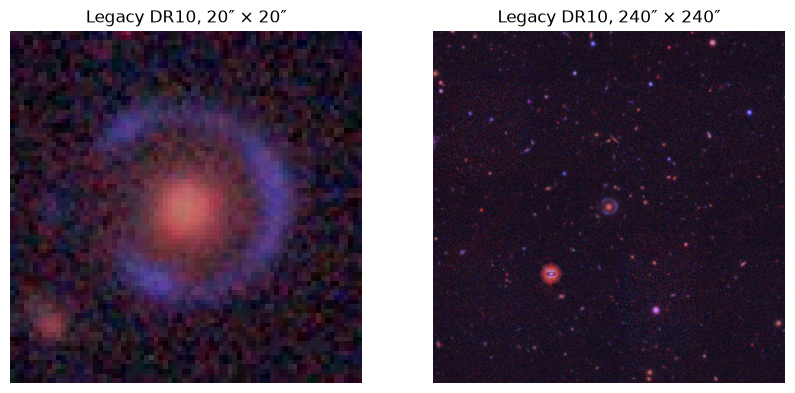

In [12]:
PIXSCALE = 0.262  # arcsec/pixel, native Legacy Surveys pixel scale
LEGACY = "https://www.legacysurvey.org/viewer"


def legacy_url(kind, size_arcsec, bands="grz"):
    size = int(round(size_arcsec / PIXSCALE))
    return f"{LEGACY}/{kind}-cutout?ra={ra:.6f}&dec={dec:.6f}&layer=ls-dr10&pixscale={PIXSCALE}&size={size}&bands={bands}"


fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, size in zip(axes, [20, 240]):
    jpeg = requests.get(legacy_url("jpeg", size), timeout=60)
    ax.imshow(plt.imread(io.BytesIO(jpeg.content), format="jpeg"))
    ax.set_title(f"Legacy DR10, {size}″ × {size}″")
    ax.axis("off")

The JPEG is only for visual inspection. Measurements use the **FITS** file, with the calibrated pixels and the WCS (the pixel ↔ sky mapping):

Filename: <class '_io.BytesIO'>
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      28   (115, 115, 3)   float32   


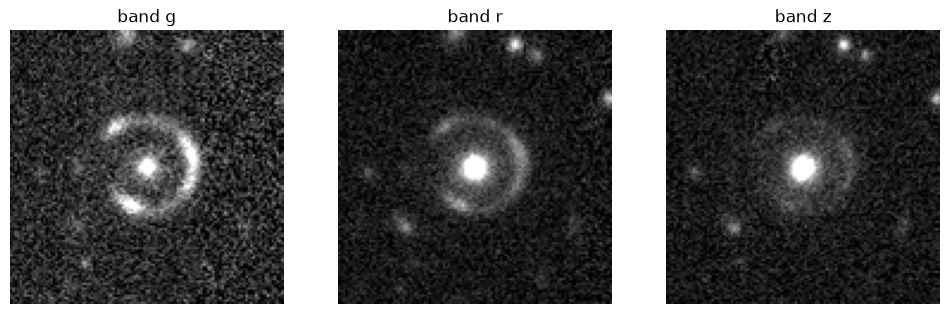

In [13]:
response = requests.get(legacy_url("fits", 30), timeout=60)
hdul = fits.open(io.BytesIO(response.content))
hdul.info()
cube = hdul[0].data  # shape: (band, y, x)
header = hdul[0].header

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, band, image in zip(axes, "grz", cube):
    ax.imshow(
        image,
        origin="lower",
        cmap="gray",
        vmin=np.percentile(image, 5),
        vmax=np.percentile(image, 99.5),
    )
    ax.set_title(f"band {band}")
    ax.axis("off")

With a survey tile, the cut is local: `Cutout2D` uses the WCS to cut a region centred on a sky position. Here the 30″ FITS plays the tile; we cut a 20″ stamp and combine *g, r, z* into a colour image:

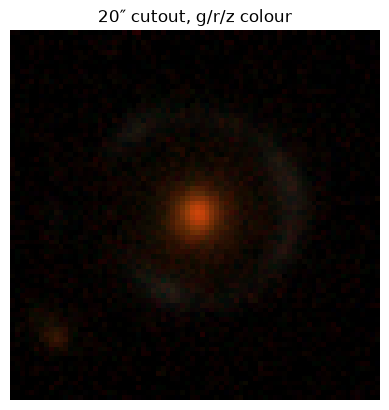

In [14]:
from astropy.nddata import Cutout2D
from astropy.visualization import make_lupton_rgb
from astropy.wcs import WCS

wcs = WCS(header).celestial
stamps = [Cutout2D(image, HORSESHOE, 20 * u.arcsec, wcs=wcs).data for image in cube]

rgb = make_lupton_rgb(stamps[2], stamps[1], stamps[0], stretch=0.5, Q=8)
plt.imshow(rgb, origin="lower")
plt.title("20″ cutout, g/r/z colour")
plt.axis("off");

The release has two kinds of colour images:

* `trilogy`: made by the pipeline from the FITS cutouts of every survey with [Trilogy](https://www.stsci.edu/~dcoe/trilogy/) (`03_Processing_Images_with_trilogy.ipynb`), for a homogeneous look in visual inspection and machine-learning training sets;
* `lsb`: colour JPEGs downloaded ready-made from the Legacy Surveys viewer (layers `ls-dr9`, `des-dr1`, `hsc-dr2` and `sdss`; `05_FITS_to_Images.ipynb`).

---
## Exercise

Repeat steps 2–4 for another system of the Diehl et al. (2009) table (e.g. `SDSS J090122.37+181432.3`):

1. find it in `database` (hint: `Individual_Coordinates` or `Original_ID`) and count how many papers report it;
2. query SDSS for a spectrum of the lens;
3. find its Legacy DR10 Tractor source;
4. download a 20″ and a 4′ cutout.

In [ ]:
# Your solution here